<a href="https://colab.research.google.com/github/Joel-Alejandro-DM/DrivenPath/blob/main/L01_03_Perceptron_Compuertas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El perceptrón y las compuertas lógicas
## Dr. Carlos Villaseñor

Paso 1. Corre la siguiente casilla para importar la paquetería necesaria.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Paso 2. Modifica la siguiente clase para que tenga un método de entrenamiento con el algoritmo del perceptrón.

In [ ]:
class Perceptron:

  def __init__(self, n_inputs, learning_rate):
    self.w = - 1 + 2 * np.random.rand(n_inputs)
    self.b = - 1 + 2 * np.random.rand()
    self.eta = learning_rate

  def predict(self, X):
    _, p = X.shape
    y_est = np.zeros(p)
    for i in range(p):
      y_est[i] = np.dot(self.w, X[:,i])+self.b
      if y_est[i] >= 0:
        y_est[i]=1
      else:
        y_est[i]=0
    return y_est

  def fit(self, X, Y, epochs=50):
    _, p = X.shape
    for _ in range(epochs):
      for i in range(p):
        # Escribe las ecuaciones del perceptrón
        y_est = self.predict(X[:,i].reshape(-1,1))
        self.w += self.eta * (Y[i] - y_est) * X[:,i]
        self.b += self.eta * (Y[i]-y_est)

Paso 3. Instancía la siguiente función para poder dibujar la línea que representa el Perceptrón.

In [ ]:
# Función para dibujar superficie de desición
def draw_2d_percep(model):
  w1, w2, b = model.w[0], model.w[1], model.b
  plt.plot([-2, 2],[(1/w2)*(-w1*(-2)-b),(1/w2)*(-w1*2-b)],'--k')

Paso 4. Corre el siguiente código para comprobar que la neurona es capaz de aprender la compuerta OR

/tmp/ipython-input-1446480218.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_est[i] = np.dot(self.w, X[:,i])+self.b


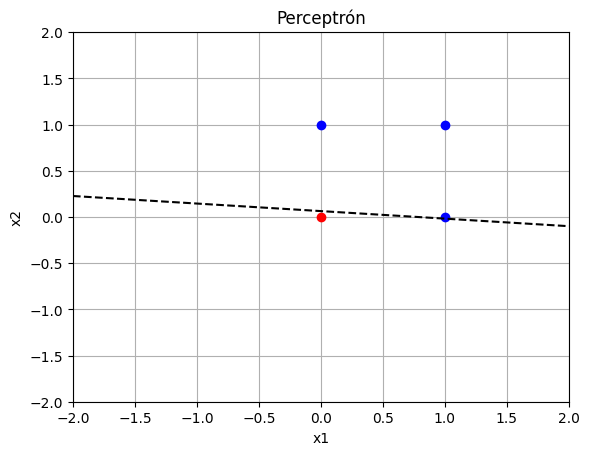

In [ ]:
# Instanciar el modelo
model = Perceptron(2, 0.1)

# Datos
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y = np.array( [0, 1, 1, 1])

# Entrenar
model.fit(X,Y)

# Predicción
model.predict(X)

# Primero dibujemos los puntos
_, p = X.shape
for i in range(p):
  if Y[i] == 0:
    plt.plot(X[0,i],X[1,i], 'or')
  else:
    plt.plot(X[0,i],X[1,i], 'ob')

plt.title('Perceptrón')
plt.grid('on')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.xlabel(r'x1')
plt.ylabel(r'x2')

draw_2d_percep(model)

Paso 5. Realiza el paso anterior con pero con los datos de la compuerta AND y de la compuerta XOR

/tmp/ipython-input-1446480218.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_est[i] = np.dot(self.w, X[:,i])+self.b


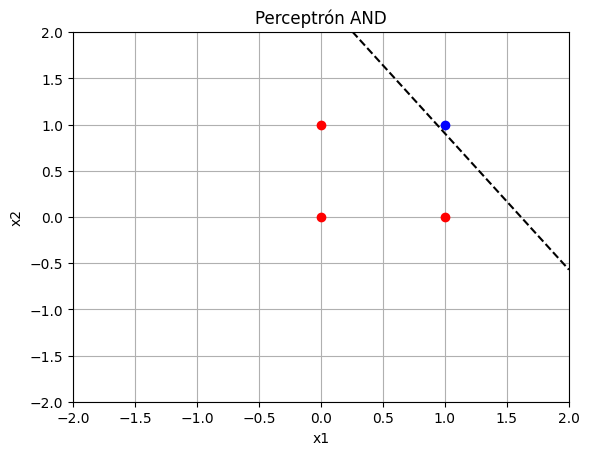

In [ ]:
# 1- Instanciar el modelo (AND)
model = Perceptron(2, 0.1)

# Datos
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y = np.array( [0, 0, 0, 1])

# Entrenar
model.fit(X,Y)

# Predicción
model.predict(X)

# Primero dibujemos los puntos
_, p = X.shape
for i in range(p):
  if Y[i] == 0:
    plt.plot(X[0,i],X[1,i], 'or')
  else:
    plt.plot(X[0,i],X[1,i], 'ob')

plt.title('Perceptrón AND')
plt.grid('on')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.xlabel(r'x1')
plt.ylabel(r'x2')

draw_2d_percep(model)

/tmp/ipython-input-1446480218.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_est[i] = np.dot(self.w, X[:,i])+self.b


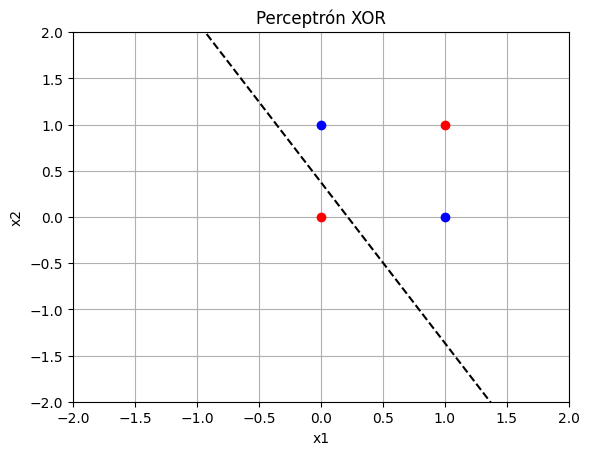

In [ ]:
# 2- Instanciar el modelo (XOR)
model = Perceptron(2, 0.1)

# Datos
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y = np.array( [0, 1, 1, 0])

# Entrenar
model.fit(X,Y)

# Predicción
model.predict(X)

# Primero dibujemos los puntos
_, p = X.shape
for i in range(p):
  if Y[i] == 0:
    plt.plot(X[0,i],X[1,i], 'or')
  else:
    plt.plot(X[0,i],X[1,i], 'ob')

plt.title('Perceptrón XOR')
plt.grid('on')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.xlabel(r'x1')
plt.ylabel(r'x2')

draw_2d_percep(model)

Paso 6. ¿Que diferencia puedes notar entre el aprendizaje de la compuerta AND y la compuerta XOR?: Escribe aquí tu respuesta

*Respuesta*: La distrubucion de los datos en el plano determinan la capacidad de ser discriminados entre si por medio de una ecuacion de una linea, para el caso de la compuerta "AND" esta linea es una recta y el perceptron es capaz de hacer la discriminación, para el caso de la "XOR" la linea no es recta, mas bien curva, para dicriminar asertadamente por lo que el aprendizaje no convergera a una solucion correcta con una linea